<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Bond%20Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 67.2 MB/s eta 0:00:00


In [14]:
import QuantLib as ql

# Valuation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

# Bond details
issue_date = ql.Date(23, 6, 2023)
maturity_date = ql.Date(23, 6, 2031)
face_amount = 100.0
coupon_rate = 0.06 # Corrected typo from copon_rate
calendar = ql.TARGET()
day_count = ql.Thirty360(ql.Thirty360.BondBasis) # Corrected day count convention
business_convention = ql.Unadjusted
frequency = ql.Semiannual

# Flat discount curve
flat_rate = 0.05
yield_curve = ql.FlatForward(today, flat_rate, ql.Actual365Fixed(), ql.Compounded, ql.Annual)
discount_curve = ql.YieldTermStructureHandle(yield_curve)

# Bond schedule
schedule = ql.Schedule(
    issue_date,
    maturity_date,
    ql.Period(frequency),
    calendar,
    business_convention,
    business_convention,
    ql.DateGeneration.Backward,
    False
)

# Fixed-rate bond
bond = ql.FixedRateBond(
    2,                  # settlement days
    face_amount,
    schedule,
    [coupon_rate],
    day_count
)

# Pricing engine
engine = ql.DiscountingBondEngine(discount_curve)
bond.setPricingEngine(engine)

# Results
clean_price = bond.cleanPrice()
dirty_price = bond.dirtyPrice()
yield_rate = bond.bondYield(day_count, ql.Compounded, frequency)

print("Clean price:", clean_price)
print("Dirty price:", dirty_price)
print("Yield:", yield_rate)

Clean price: 104.6283594553022
Dirty price: 104.66169278863553
Yield: 0.04942145347595215


In [18]:
import QuantLib as ql

# Evaluation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

calendar = ql.TARGET()
settlement_days = 2 # Corrected typo from sستtlement_days
face_amount = 100.0

# Flat discount curve
flat_rate = 0.05
discount_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, flat_rate, ql.Actual365Fixed())
)

# Floating index setup
index_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.04, ql.Actual365Fixed())
)

ibor_index = ql.Euribor3M(index_curve)

# Bond schedule
issue_date = ql.Date(23, 6, 2024)
maturity_date = ql.Date(23, 6, 2030)

schedule = ql.Schedule(
    issue_date,
    maturity_date,
    ql.Period(ql.Semiannual),
    calendar,
    ql.ModifiedFollowing,
    ql.ModifiedFollowing,
    ql.DateGeneration.Backward,
    False
)

# Floating-rate bond: index + spread
spread = 0.0025  # 25 bps
bond = ql.FloatingRateBond(
    settlement_days,
    face_amount,
    schedule,
    ibor_index,
    ql.Actual360(),
    ql.ModifiedFollowing,
    fixingDays=2,
    spreads=[spread]
)

# QuantLib requires explicit fixings for past dates relative to the evaluation date.
# The previous RuntimeError indicated a missing fixing for June 19th, 2026.
# Add the specific fixing for the required date, using the rate from the index_curve.
ibor_index.addFixing(ql.Date(19, 6, 2026), 0.04)

# Pricing engine
engine = ql.DiscountingBondEngine(discount_curve)
bond.setPricingEngine(engine)

print("Clean price:", bond.cleanPrice())
print("Dirty price:", bond.dirtyPrice())
print("Accrued:", bond.accruedAmount())

Clean price: 97.25274051294767
Dirty price: 97.27635162405878
Accrued: 0.02361111111111111


In [19]:
import QuantLib as ql

# Valuation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
settlement_days = 2
face_amount = 100.0

# Discount curve
discount_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.05, ql.Actual365Fixed())
)

# SOFR curve for forwards / coupon projection
sofr_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.045, ql.Actual365Fixed())
)

# SOFR index
sofr = ql.Sofr(sofr_curve)

# Bond schedule
issue_date = ql.Date(23, 6, 2024)
maturity_date = ql.Date(23, 6, 2030)

schedule = ql.Schedule(
    issue_date,
    maturity_date,
    ql.Period(ql.Quarterly),
    calendar,
    ql.ModifiedFollowing,
    ql.ModifiedFollowing,
    ql.DateGeneration.Backward,
    False
)

# Floating-rate bond: SOFR + spread
spread = 0.005  # 50 bps
bond = ql.FloatingRateBond(
    settlement_days,
    face_amount,
    schedule,
    sofr,
    ql.Actual360(),
    ql.ModifiedFollowing,
    fixingDays=0,
    spreads=[spread]
)

# Add historical fixings if any coupon has already started
for d in schedule:
    if d < today:
        try:
            sofr.addFixing(d, 0.045)
        except:
            pass

bond.setPricingEngine(ql.DiscountingBondEngine(discount_curve))

print("Clean price:", bond.cleanPrice())
print("Dirty price:", bond.dirtyPrice())
print("Accrued:", bond.accruedAmount())

Clean price: 100.00329380651921
Dirty price: 100.03086948736997
Accrued: 0.02757568085075802


In [21]:
import QuantLib as ql

# Evaluation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
settlement_days = 2
day_count = ql.Actual360()

# Market quotes
deposits = [
    (ql.Period("1M"), 0.0500),
    (ql.Period("3M"), 0.0515),
    (ql.Period("6M"), 0.0530),
]

swaps = [
    (ql.Period("1Y"), 0.0540),
    (ql.Period("2Y"), 0.0560),
    (ql.Period("3Y"), 0.0575),
    (ql.Period("5Y"), 0.0590),
]

helpers = []

# Deposit helpers
for tenor, rate in deposits:
    quote = ql.QuoteHandle(ql.SimpleQuote(rate))
    helper = ql.DepositRateHelper(
        quote,
        tenor,
        settlement_days,
        calendar,
        ql.ModifiedFollowing,
        False,
        day_count
    )
    helpers.append(helper)

# Swap helpers
fixed_leg_frequency = ql.Annual
fixed_leg_convention = ql.Unadjusted
fixed_leg_day_count = ql.Thirty360(ql.Thirty360.BondBasis) # Corrected: Added convention argument
float_index = ql.USDLibor(ql.Period("3M"))

for tenor, rate in swaps:
    quote = ql.QuoteHandle(ql.SimpleQuote(rate))
    helper = ql.SwapRateHelper(
        quote,
        tenor,
        calendar,
        fixed_leg_frequency,
        fixed_leg_convention,
        fixed_leg_day_count,
        float_index
    )
    helpers.append(helper)

# Bootstrap curve
curve = ql.PiecewiseLinearZero(today, helpers, ql.Actual365Fixed())
curve.enableExtrapolation()
curve_handle = ql.YieldTermStructureHandle(curve)

# Example: inspect zero rates
for d in [ql.Date(23, 9, 2026), ql.Date(23, 6, 2027), ql.Date(23, 6, 2028)]:
    zr = curve.zeroRate(d, ql.Actual365Fixed(), ql.Continuous).rate()
    print(d, zr)

September 23rd, 2026 0.05180498907018257
June 23rd, 2027 0.05259051733412494
June 23rd, 2028 0.05436714267558694


In [23]:
import QuantLib as ql

# Valuation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

# Example zero curve inputs
dates = [
    ql.Date(23, 6, 2026),
    ql.Date(23, 12, 2026),
    ql.Date(23, 6, 2027),
    ql.Date(23, 6, 2028),
]
rates = [0.050, 0.052, 0.054, 0.056]

day_count = ql.Actual365Fixed()
calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond) # Corrected: Added market argument

curve = ql.ZeroCurve(dates, rates, day_count, calendar)
curve_handle = ql.YieldTermStructureHandle(curve)

# Bond example
issue_date = ql.Date(23, 6, 2024)
maturity_date = ql.Date(23, 6, 2028)
schedule = ql.Schedule(
    issue_date, maturity_date, ql.Period(ql.Semiannual),
    calendar, ql.Unadjusted, ql.Unadjusted,
    ql.DateGeneration.Backward, False
)

bond = ql.FixedRateBond(
    2, 100.0, schedule, [0.06], ql.Thirty360(ql.Thirty360.BondBasis) # Corrected: Added convention argument
)

bond.setPricingEngine(ql.DiscountingBondEngine(curve_handle))

print("Clean price:", bond.cleanPrice())
print("Dirty price:", bond.dirtyPrice())

Clean price: 100.59399490228512
Dirty price: 100.62732823561845


In [24]:
import QuantLib as ql

today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

# Example discount curve used by DiscountingBondEngine
curve = ql.FlatForward(today, 0.05, ql.Actual365Fixed())
yts = ql.YieldTermStructureHandle(curve)

# Bond
calendar = ql.TARGET()
issue_date = ql.Date(23, 6, 2024)
maturity_date = ql.Date(23, 6, 2030)

schedule = ql.Schedule(
    issue_date, maturity_date, ql.Period(ql.Semiannual),
    calendar, ql.Unadjusted, ql.Unadjusted,
    ql.DateGeneration.Backward, False
)

bond = ql.FixedRateBond(
    2, 100.0, schedule, [0.06], ql.Thirty360(ql.Thirty360.BondBasis)
)

bond.setPricingEngine(ql.DiscountingBondEngine(yts))

# Price
print("Clean price:", bond.cleanPrice())

# Zero rates from the discount curve
for years in [1, 2, 3, 5]:
    d = calendar.advance(today, ql.Period(years, ql.Years))
    zr = yts.zeroRate(d, ql.Actual365Fixed(), ql.Continuous).rate()
    print(years, "Y zero rate:", zr)

Clean price: 103.32181249008055
1 Y zero rate: 0.05000000000000007
2 Y zero rate: 0.04999999999999998
3 Y zero rate: 0.04999999999999999
5 Y zero rate: 0.04999999999999999


In [25]:
import numpy as np

# Example: maturity times in years
T = np.array([1, 2, 3])

# Example bond market prices
P = np.array([99.5, 98.8, 97.2])

# Example coupon cash flows per bond (simplified)
# rows = payment dates, cols = bonds
cashflows = np.array([
    [105.0,  5.0,  5.0],
    [  0.0, 105.0,  5.0],
    [  0.0,   0.0, 105.0]
])

discounts = np.zeros(len(T))

for i in range(len(T)):
    known_pv = 0.0
    for j in range(i):
        known_pv += cashflows[j, i] * discounts[j]
    discounts[i] = (P[i] - known_pv) / cashflows[i, i]

zero_rates = -np.log(discounts) / T
print(discounts)
print(zero_rates)

[0.94761905 0.89582766 0.83793111]
[0.05380271 0.05500361 0.0589398 ]


In [27]:
import QuantLib as ql

# Evaluation date
today = ql.Date(23, 6, 2026)
ql.Settings.instance().evaluationDate = today

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
settlement_days = 2
day_count = ql.Actual365Fixed()

# Market quotes
deposits = [
    (ql.Period("1M"), 0.0500),
    (ql.Period("3M"), 0.0515),
    (ql.Period("6M"), 0.0530),
]

swaps = [
    (ql.Period("1Y"), 0.0540),
    (ql.Period("2Y"), 0.0560),
    (ql.Period("3Y"), 0.0575),
    (ql.Period("5Y"), 0.0590),
]

helpers = []

# Deposit helpers
for tenor, rate in deposits:
    helpers.append(
        ql.DepositRateHelper(
            ql.QuoteHandle(ql.SimpleQuote(rate)),
            tenor,
            settlement_days,
            calendar,
            ql.ModifiedFollowing,
            False,
            ql.Actual360()
        )
    )

# Swap helpers
float_index = ql.Sofr()  # or ql.USDLibor(ql.Period("3M")) for legacy LIBOR-style examples
for tenor, rate in swaps:
    helpers.append(
        ql.SwapRateHelper(
            ql.QuoteHandle(ql.SimpleQuote(rate)),
            tenor,
            calendar,
            ql.Annual,
            ql.Unadjusted,
            ql.Thirty360(ql.Thirty360.BondBasis),
            float_index
        )
    )

# Piecewise curve
curve = ql.PiecewiseLogLinearDiscount(
    settlement_days,
    calendar,
    helpers,
    day_count
)

curve.enableExtrapolation()
curve_handle = ql.YieldTermStructureHandle(curve)

# Query curve
for years in [0.5, 1, 2, 3, 5]:
    d = calendar.advance(today, ql.Period(int(years * 12), ql.Months))
    zr = curve.zeroRate(d, ql.Actual365Fixed(), ql.Continuous).rate()
    df = curve.discount(d)
    print(years, "Y zero:", zr, "discount:", df)


0.5 Y zero: 0.05298274419986645 discount: 0.9740685141000713
1 Y zero: 0.05288221568456381 discount: 0.9487666034155614
2 Y zero: 0.05461613566115138 discount: 0.8966563164855361
3 Y zero: 0.05597628660822048 discount: 0.8452843329604519
5 Y zero: 0.05756272068639308 discount: 0.7500196315848441


In [33]:
import QuantLib as ql


class CurveBootstrapTemplate:
    def __init__(self, valuation_date, calendar, day_counter):
        self.valuation_date = valuation_date
        self.calendar = calendar
        self.day_counter = day_counter

        ql.Settings.instance().evaluationDate = valuation_date

    def build_ois_discount_curve(
        self,
        currency_name,
        overnight_index,
        deposit_quotes=None,
        ois_quotes=None,
        settlement_days=2,
        fixed_freq=ql.Annual,
        fixed_convention=ql.ModifiedFollowing,
        fixed_dc=ql.Actual360(),
        pillar=ql.Pillar.LastRelevantDate,
    ):
        helpers = []

        deposit_quotes = deposit_quotes or []
        ois_quotes = ois_quotes or []

        # Overnight deposits / short cash
        for tenor_str, rate in deposit_quotes:
            quote = ql.SimpleQuote(rate)
            tenor = ql.Period(tenor_str)
            helper = ql.DepositRateHelper(
                ql.QuoteHandle(quote),
                tenor,
                settlement_days,
                self.calendar,
                ql.ModifiedFollowing,
                False,
                self.day_counter,
            )
            helpers.append(helper)

        # OIS swaps
        for tenor_str, rate in ois_quotes:
            quote = ql.SimpleQuote(rate)
            tenor = ql.Period(tenor_str)
            helper = ql.OISRateHelper(
                settlement_days,
                tenor,
                ql.QuoteHandle(quote),
                overnight_index,
            )
            helpers.append(helper)

        curve = ql.PiecewiseLogLinearDiscount(
            self.valuation_date,
            helpers,
            self.day_counter,
        )
        curve.enableExtrapolation()

        print(f"{currency_name} OIS discount curve built with {len(helpers)} helpers")
        return curve

    def build_ibor_forward_curve(
        self,
        currency_name,
        ibor_index,
        discount_curve,
        deposit_quotes=None,
        fra_quotes=None,
        swap_quotes=None,
        settlement_days=2,
        fixed_freq=ql.Annual,
        fixed_convention=ql.ModifiedFollowing,
        fixed_dc=ql.Thirty360(ql.Thirty360.BondBasis),
    ):
        helpers = []

        deposit_quotes = deposit_quotes or []
        fra_quotes = fra_quotes or []
        swap_quotes = swap_quotes or []

        # Short deposits
        for tenor_str, rate in deposit_quotes:
            quote = ql.SimpleQuote(rate)
            tenor = ql.Period(tenor_str)
            helper = ql.DepositRateHelper(
                ql.QuoteHandle(quote),
                tenor,
                settlement_days,
                self.calendar,
                ql.ModifiedFollowing,
                False,
                ibor_index.dayCounter(),
            )
            helpers.append(helper)

        # FRAs
        for months_to_start, months_to_end, rate in fra_quotes:
            quote = ql.SimpleQuote(rate)
            helper = ql.FraRateHelper(
                ql.QuoteHandle(quote),
                months_to_start,
                months_to_end,
                settlement_days,
                self.calendar,
                ql.ModifiedFollowing,
                False,
                ibor_index.dayCounter(),
            )
            helpers.append(helper)

        # IRS
        discount_handle = ql.YieldTermStructureHandle(discount_curve)

        for tenor_str, rate in swap_quotes:
            quote = ql.SimpleQuote(rate)
            tenor = ql.Period(tenor_str)
            helper = ql.SwapRateHelper(
                ql.QuoteHandle(quote),
                tenor,
                self.calendar,
                fixed_freq,
                fixed_convention,
                fixed_dc,
                ibor_index,
                ql.QuoteHandle(),
                ql.Period(0, ql.Days),
                discount_handle,
            )
            helpers.append(helper)

        curve = ql.PiecewiseLogLinearDiscount(
            self.valuation_date,
            helpers,
            ibor_index.dayCounter(),
        )
        curve.enableExtrapolation()

        print(f"{currency_name} IBOR forward curve built with {len(helpers)} helpers")
        return curve


def print_curve_sample(curve, day_counter, label, tenors):
    print(f"\n{label}")
    print("-" * 60)
    today = ql.Settings.instance().evaluationDate
    for tenor_str in tenors:
        d = today + ql.Period(tenor_str)
        zr = curve.zeroRate(d, day_counter, ql.Compounded, ql.Annual).rate()
        df = curve.discount(d)
        print(f"{tenor_str:>4} | DF={df:0.8f} | Zero={100*zr:0.4f}%")


if __name__ == "__main__":
    valuation_date = ql.Date(23, 6, 2026)

    # -----------------------------
    # USD setup
    # -----------------------------
    usd_calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    usd_dc = ql.Actual360()

    usd_builder = CurveBootstrapTemplate(
        valuation_date=valuation_date,
        calendar=usd_calendar,
        day_counter=usd_dc,
    )

    # Replace sample quotes with live market inputs
    usd_ois_deposits = [
        ("1D", 0.0525),
        ("1W", 0.0527),
        # ("1M", 0.0530), # Removed due to pillar collision with 1M OIS swap
    ]

    usd_ois_swaps = [
        ("1M", 0.0531),
        ("3M", 0.0533),
        ("6M", 0.0535),
        ("1Y", 0.0528),
        ("2Y", 0.0498),
        ("3Y", 0.0469),
        ("5Y", 0.0428),
        ("7Y", 0.0406),
        ("10Y", 0.0388),
        ("30Y", 0.0369),
    ]

    usd_overnight = ql.Sofr()

    usd_discount_curve = usd_builder.build_ois_discount_curve(
        currency_name="USD",
        overnight_index=usd_overnight,
        deposit_quotes=usd_ois_deposits,
        ois_quotes=usd_ois_swaps,
        settlement_days=2,
    )

    # Optional USD forward curve, e.g. term SOFR / legacy LIBOR-style structure
    usd_ibor = ql.USDLibor(ql.Period("3M"), ql.YieldTermStructureHandle(usd_discount_curve))

    usd_fwd_deposits = [
        ("3M", 0.0536),
    ]

    usd_fras = [
        (3, 6, 0.0539),
        (6, 9, 0.0534),
        (9, 12, 0.0526),
    ]

    usd_swaps = [
        ("2Y", 0.0499),
        ("3Y", 0.0470),
        ("5Y", 0.0429),
        ("7Y", 0.0408),
        ("10Y", 0.0390),
        ("30Y", 0.0371),
    ]

    usd_forward_curve = usd_builder.build_ibor_forward_curve(
        currency_name="USD",
        ibor_index=usd_ibor,
        discount_curve=usd_discount_curve,
        deposit_quotes=usd_fwd_deposits,
        fra_quotes=usd_fras,
        swap_quotes=usd_swaps,
        settlement_days=2,
        fixed_freq=ql.Semiannual,
        fixed_convention=ql.ModifiedFollowing,
        fixed_dc=ql.Thirty360(ql.Thirty360.BondBasis),
    )

    print_curve_sample(
        usd_discount_curve,
        usd_dc,
        "USD Discount Curve Sample",
        ["1M", "3M", "6M", "1Y", "2Y", "5Y", "10Y", "30Y"],
    )

    # -----------------------------
    # EUR setup
    # -----------------------------
    eur_calendar = ql.TARGET()
    eur_dc = ql.Actual360()

    eur_builder = CurveBootstrapTemplate(
        valuation_date=valuation_date,
        calendar=eur_calendar,
        day_counter=eur_dc,
    )

    eur_ois_deposits = [
        ("1D", 0.0310),
        ("1W", 0.0311),
        # ("1M", 0.0313), # Removed due to pillar collision with 1M OIS swap
    ]

    eur_ois_swaps = [
        ("1M", 0.0314),
        ("3M", 0.0316),
        ("6M", 0.0319),
        ("1Y", 0.0312),
        ("2Y", 0.0291),
        ("3Y", 0.0270),
        ("5Y", 0.0245),
        ("7Y", 0.0232),
        ("10Y", 0.0220),
        ("30Y", 0.0208),
    ]

    eur_overnight = ql.Eonia()  # In newer setups, users often switch to €STR-linked conventions

    eur_discount_curve = eur_builder.build_ois_discount_curve(
        currency_name="EUR",
        overnight_index=eur_overnight,
        deposit_quotes=eur_ois_deposits,
        ois_quotes=eur_ois_swaps,
        settlement_days=2,
    )

    eur_ibor = ql.Euribor3M(ql.YieldTermStructureHandle(eur_discount_curve))

    eur_fwd_deposits = [
        ("3M", 0.0318),
    ]

    eur_fras = [
        (3, 6, 0.0320),
        (6, 9, 0.0315),
        (9, 12, 0.0308),
    ]

    eur_swaps = [
        ("2Y", 0.0292),
        ("3Y", 0.0271),
        ("5Y", 0.0247),
        ("7Y", 0.0234),
        ("10Y", 0.0222),
        ("30Y", 0.0210),
    ]

    eur_forward_curve = eur_builder.build_ibor_forward_curve(
        currency_name="EUR",
        ibor_index=eur_ibor,
        discount_curve=eur_discount_curve,
        deposit_quotes=eur_fwd_deposits,
        fra_quotes=eur_fras,
        swap_quotes=eur_swaps,
        settlement_days=2,
        fixed_freq=ql.Annual,
        fixed_convention=ql.ModifiedFollowing,
        fixed_dc=ql.Thirty360(ql.Thirty360.BondBasis),
    )

    print_curve_sample(
        eur_discount_curve,
        eur_dc,
        "EUR Discount Curve Sample",
        ["1M", "3M", "6M", "1Y", "2Y", "5Y", "10Y", "30Y"],
    )


USD OIS discount curve built with 12 helpers
USD IBOR forward curve built with 10 helpers

USD Discount Curve Sample
------------------------------------------------------------
  1M | DF=0.99559872 | Zero=5.4358%
  3M | DF=0.98656426 | Zero=5.4357%
  6M | DF=0.97352919 | Zero=5.4193%
  1Y | DF=0.94917393 | Zero=5.2795%
  2Y | DF=0.90615415 | Zero=4.9728%
  5Y | DF=0.80995262 | Zero=4.2431%
 10Y | DF=0.68353356 | Zero=3.8208%
 30Y | DF=0.33805019 | Zero=3.6273%
EUR OIS discount curve built with 12 helpers
EUR IBOR forward curve built with 10 helpers

EUR Discount Curve Sample
------------------------------------------------------------
  1M | DF=0.99739320 | Zero=3.1818%
  3M | DF=0.99199209 | Zero=3.1962%
  6M | DF=0.98405074 | Zero=3.2134%
  1Y | DF=0.96932997 | Zero=3.1200%
  2Y | DF=0.94345996 | Zero=2.9078%
  5Y | DF=0.88502894 | Zero=2.4371%
 10Y | DF=0.80351099 | Zero=2.1793%
 30Y | DF=0.53772281 | Zero=2.0591%


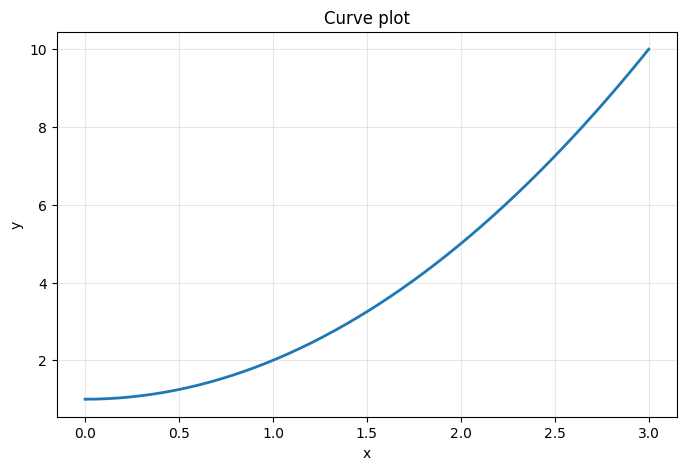

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Example curve: y = x^2 + 1
x = np.linspace(0, 3, 200)
y = x**2 + 1

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve plot")
plt.grid(True, alpha=0.3)
plt.show()